# Training KIND model on filtered TESLA data

The data is supposed to be filtered into stationary- and transient-like data snippets. The data is used to train the full version of KIND model.

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

### KIND training

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--dataset_id', 'kind-detuning-meas',
        '--file_dir', '../../data/kalman',
        '--file_name', 'tesla_meas',
        '--data_nsample', '144',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
    ]
)


In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

### Training the mean of a stationary operator

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.791538, valid=0.489342, test=0.485981
	validation loss decreased (inf -> 0.489342), saving model ...
	epoch 2 losses: train=1.350788, valid=0.266828, test=0.271941
	validation loss decreased (0.489342 -> 0.266828), saving model ...
	epoch 3 losses: train=0.898330, valid=0.239495, test=0.242465
	validation loss decreased (0.266828 -> 0.239495), saving model ...
	epoch 4 losses: train=0.844822, valid=0.236148, test=0.237540
	validation loss decreased (0.239495 -> 0.236148), saving model ...
	epoch 5 losses: train=0.837866, valid=0.233872, test=0.235982
	validation loss decreased (0.236148 -> 0.233872), saving model ...
	epoch 6 losses: train=0.832178, valid=0.231882, test=0.234565
	validation loss decreased (0.233872 -> 0.231882), saving model ...
	epoch 7 losses: train=0.829392, valid=0.230765, test=0.234622
	validation loss decreased (0.231882 -> 0.230765), saving model ...
	epoch 8 losses: train=0.822646, valid=0.228453, test=0.23

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

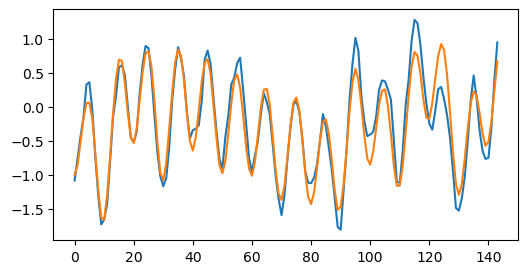

In [6]:
jdata = 9

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

### Training the uncertainty of a stationary operator

In [7]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.533793, valid=0.378957, test=0.377010
	validation loss decreased (inf -> 0.378957), saving model ...
	epoch 2 losses: train=0.355974, valid=0.353691, test=0.352074
	validation loss decreased (0.378957 -> 0.353691), saving model ...
	epoch 3 losses: train=0.342109, valid=0.345062, test=0.343335
	validation loss decreased (0.353691 -> 0.345062), saving model ...
	epoch 4 losses: train=0.334645, valid=0.340564, test=0.337774
	validation loss decreased (0.345062 -> 0.340564), saving model ...
	epoch 5 losses: train=0.330390, valid=0.337309, test=0.336011
	validation loss decreased (0.340564 -> 0.337309), saving model ...
	epoch 6 losses: train=0.328893, valid=0.336128, test=0.333146
	validation loss decreased (0.337309 -> 0.336128), saving model ...
	epoch 7 losses: train=0.327969, valid=0.334860, test=0.331073
	validation loss decreased (0.336128 -> 0.334860), saving model ...
	epoch 8 losses: train=0.321177, valid=0.321490, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

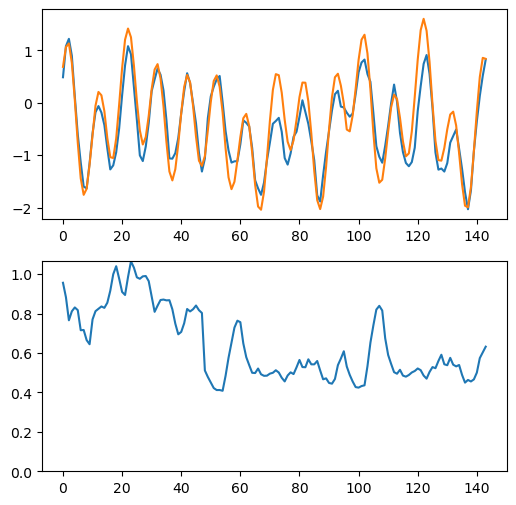

In [9]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

### Training the mean of a transient operator

In [10]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=1.768746, valid=1.441756, test=1.430919
	validation loss decreased (inf -> 1.441756), saving model ...
	epoch 2 losses: train=1.447484, valid=0.992365, test=0.986842
	validation loss decreased (1.441756 -> 0.992365), saving model ...
	epoch 3 losses: train=1.144693, valid=0.779622, test=0.767443
	validation loss decreased (0.992365 -> 0.779622), saving model ...
	epoch 4 losses: train=0.831205, valid=0.591808, test=0.584898
	validation loss decreased (0.779622 -> 0.591808), saving model ...
	epoch 5 losses: train=0.711225, valid=0.541234, test=0.535007
	validation loss decreased (0.591808 -> 0.541234), saving model ...
	epoch 6 losses: train=0.673551, valid=0.525447, test=0.518898
	validation loss decreased (0.541234 -> 0.525447), saving model ...
	epoch 7 losses: train=0.655397, valid=0.514746, test=0.511414
	validation loss decreased (0.525447 -> 0.514746), saving model ...
	epoch 8 losses: train=0.630055, valid=0.488674, test=0.484

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='trans')

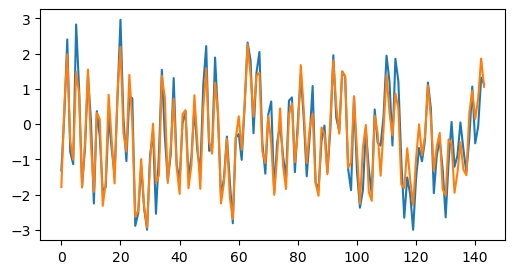

In [12]:
jdata = 21

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

### Training the uncertainty of a transient operator

In [13]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=0.382144, valid=0.079765, test=0.080691
	validation loss decreased (inf -> 0.079765), saving model ...
	epoch 2 losses: train=0.041356, valid=0.005763, test=0.012872
	validation loss decreased (0.079765 -> 0.005763), saving model ...
	epoch 3 losses: train=-0.040093, valid=-0.062425, test=-0.053331
	validation loss decreased (0.005763 -> -0.062425), saving model ...
	epoch 4 losses: train=-0.104080, valid=-0.093975, test=-0.083841
	validation loss decreased (-0.062425 -> -0.093975), saving model ...
	epoch 5 losses: train=-0.158964, valid=-0.162709, test=-0.155989
	validation loss decreased (-0.093975 -> -0.162709), saving model ...
	epoch 6 losses: train=-0.005287, valid=-0.060562, test=-0.049700
	early stopping counter: 1 out of 30
	epoch 7 losses: train=-0.115040, valid=-0.137756, test=-0.126063
	early stopping counter: 2 out of 30
	epoch 8 losses: train=-0.116451, valid=1.010459, test=-0.098411
	early stopping counter: 3 ou

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

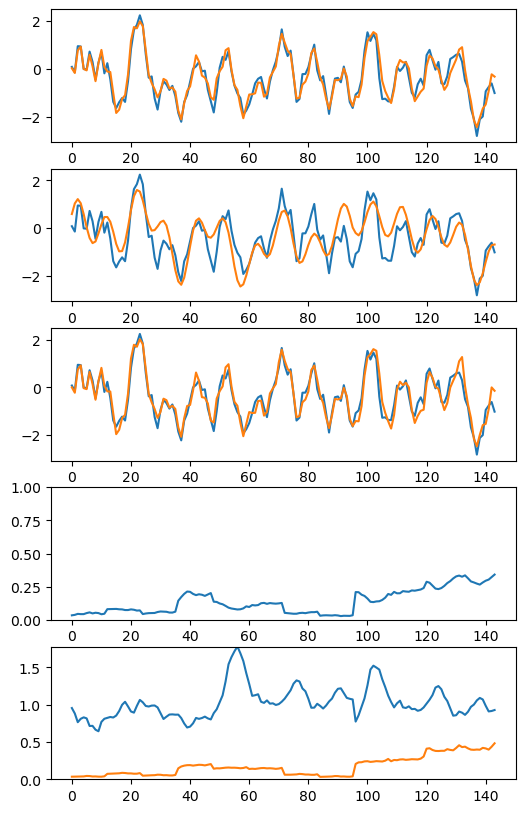

In [15]:
jdata = 30

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])
        plt.ylim((0., 1.))

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break